# Day 045: Hyperparameter Tuning Frameworks (GridSearch, RandomizedSearch, & Optuna)

Welcome to **Day 045** of the AI/ML Roadmap! In this notebook, we will master hyperparameter optimization for Gradient Boosting models (LightGBM & XGBoost).

### 🎯 Key Topics Covered:
1. **GridSearchCV**: Exhaustive search across a fixed hyperparameter grid.
2. **RandomizedSearchCV**: Random sampling across parameter distributions.
3. **Optuna Framework**: Bayesian optimization with **Tree-structured Parzen Estimator (TPE)**.
4. **Optuna Suggest API**: `suggest_float`, `suggest_int`, `suggest_categorical`, `log=True` sampling.
5. **Pruning Unpromising Trials**: Early stopping bad trials using `MedianPruner`.
6. **Optuna Visualizations**: `plot_optimization_history`, `plot_param_importances`, `plot_parallel_coordinate`.
7. **Comparative Benchmark**: Speed vs Accuracy comparison between GridSearch, RandomizedSearch, and Optuna.

## 1. Setup & Environment Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ML Models & Scikit-Learn Utilities
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from scipy.stats import randint, uniform

import lightgbm as lgb
import xgboost as xgb
import optuna

# Suppress verbose logs from Optuna for clean output
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"Optuna Version: {optuna.__version__}")
print(f"LightGBM Version: {lgb.__version__}")
print(f"XGBoost Version: {xgb.__version__}")

Optuna Version: 4.9.0
LightGBM Version: 4.7.0
XGBoost Version: 3.1.2


## 2. Dataset Preparation
We will generate a synthetic binary classification dataset with 5,000 samples and 20 features to benchmark hyperparameter search methods.

In [2]:
# Generate synthetic binary dataset
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_repeated=0,
    n_classes=2,
    weights=[0.6, 0.4],
    random_state=42
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape:  {X_test.shape}")
print(f"Class Distribution in Train: {np.bincount(y_train)}")

Training Set Shape: (4000, 20)
Testing Set Shape:  (1000, 20)
Class Distribution in Train: [2393 1607]


## 3. Baseline Model Performance
Let's evaluate a default LightGBM model to set our baseline performance benchmark.

In [3]:
# Train default LightGBM model
baseline_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
start_time = time.time()
baseline_model.fit(X_train, y_train)
baseline_time = time.time() - start_time

y_pred_baseline = baseline_model.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, y_pred_baseline)

print(f"⚡ Baseline LightGBM Test ROC-AUC Score: {baseline_auc:.5f}")
print(f"⏱️ Training Time: {baseline_time:.4f} seconds")

⚡ Baseline LightGBM Test ROC-AUC Score: 0.98705
⏱️ Training Time: 1.7277 seconds


## 4. Traditional Hyperparameter Tuning: GridSearchCV vs RandomizedSearchCV

- **GridSearchCV**: Evaluates every single combination in a predefined grid. Thorough but exponentially slow as parameters increase.
- **RandomizedSearchCV**: Samples fixed number of parameter combinations randomly from specified probability distributions. Faster, but might miss optimal regions.

In [4]:
# --- 1. GridSearchCV ---
param_grid = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7]
}

print("🔍 Running GridSearchCV (3x3x3x3 = 81 combinations)...")
grid_search = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
start_time = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

grid_auc = roc_auc_score(y_test, grid_search.predict_proba(X_test)[:, 1])
print(f"✅ GridSearchCV Best CV Score: {grid_search.best_score_:.5f}")
print(f"⚡ GridSearchCV Test ROC-AUC: {grid_auc:.5f}")
print(f"⏱️ Execution Time: {grid_time:.2f} seconds\n")

# --- 2. RandomizedSearchCV ---
param_dist = {
    'num_leaves': randint(15, 127),
    'learning_rate': uniform(0.01, 0.2),
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

print("🎲 Running RandomizedSearchCV (50 iterations)...")
rand_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
start_time = time.time()
rand_search.fit(X_train, y_train)
rand_time = time.time() - start_time

rand_auc = roc_auc_score(y_test, rand_search.predict_proba(X_test)[:, 1])
print(f"✅ RandomizedSearchCV Best CV Score: {rand_search.best_score_:.5f}")
print(f"⚡ RandomizedSearchCV Test ROC-AUC: {rand_auc:.5f}")
print(f"⏱️ Execution Time: {rand_time:.2f} seconds")

🔍 Running GridSearchCV (3x3x3x3 = 81 combinations)...
✅ GridSearchCV Best CV Score: 0.98343
⚡ GridSearchCV Test ROC-AUC: 0.98636
⏱️ Execution Time: 45.57 seconds

🎲 Running RandomizedSearchCV (50 iterations)...
✅ RandomizedSearchCV Best CV Score: 0.98442
⚡ RandomizedSearchCV Test ROC-AUC: 0.98745
⏱️ Execution Time: 39.26 seconds


## 5. Optuna Framework & Bayesian Optimization

Optuna uses **Tree-structured Parzen Estimator (TPE)**, a Bayesian optimization technique that builds a probabilistic model of the objective function to select the most promising hyperparameters for subsequent trials.

### Key APIs in Optuna Objective Function:
- `trial.suggest_float('name', low, high, log=True)`: For continuous variables like `learning_rate`, `reg_alpha`, `reg_lambda`.
- `trial.suggest_int('name', low, high, step=1)`: For integer parameters like `num_leaves`, `max_depth`, `n_estimators`.
- `trial.suggest_categorical('name', ['val1', 'val2'])`: For discrete choices.

In [5]:
def objective(trial):
    # 1. Define hyperparameter search space
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 400, step=25),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42
    }
    
    # 2. Stratified 5-Fold Cross Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, y_tr = X_train[train_idx], y_train[train_idx]
        X_va, y_va = X_train[val_idx], y_train[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict_proba(X_va)[:, 1]
        auc = roc_auc_score(y_va, preds)
        scores.append(auc)
        
    return np.mean(scores)

# Create & Optimize Study
print("🚀 Launching Optuna Study (50 trials with TPE Sampler)... ")
start_time = time.time()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=False)

optuna_time = time.time() - start_time

print(f"✨ Best Trial CV ROC-AUC: {study.best_value:.5f}")
print(f"⏱️ Optuna Execution Time: {optuna_time:.2f} seconds")
print("\n🏆 Best Hyperparameters Found by Optuna:")
for k, v in study.best_params.items():
    print(f"  - {k}: {v}")

🚀 Launching Optuna Study (50 trials with TPE Sampler)... 
✨ Best Trial CV ROC-AUC: 0.98341
⏱️ Optuna Execution Time: 73.02 seconds

🏆 Best Hyperparameters Found by Optuna:
  - boosting_type: gbdt
  - num_leaves: 30
  - max_depth: 12
  - learning_rate: 0.15348394073614546
  - n_estimators: 175
  - min_child_samples: 49
  - subsample: 0.5872716435209319
  - colsample_bytree: 0.820963944431039
  - reg_alpha: 0.02308767609241222
  - reg_lambda: 0.000617425336361067


## 6. Train & Evaluate Final Model using Best Optuna Params

In [6]:
# Train final model on full training set using best parameters
best_params = study.best_params.copy()
best_params['objective'] = 'binary'
best_params['metric'] = 'auc'
best_params['verbosity'] = -1
best_params['random_state'] = 42

final_optuna_model = lgb.LGBMClassifier(**best_params)
final_optuna_model.fit(X_train, y_train)

optuna_test_auc = roc_auc_score(y_test, final_optuna_model.predict_proba(X_test)[:, 1])
print(f"🔥 Final Optuna Model Test ROC-AUC: {optuna_test_auc:.5f}")

🔥 Final Optuna Model Test ROC-AUC: 0.98781


## 7. Pruning Unpromising Trials (`MedianPruner`)

Optuna allows stopping trials early if initial folds perform significantly worse than median of previous trials. This saves up to 70% compute time.

In [7]:
def objective_with_pruning(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': 300,
        'random_state': 42
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, y_tr = X_train[train_idx], y_train[train_idx]
        X_va, y_va = X_train[val_idx], y_train[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        
        auc = roc_auc_score(y_va, model.predict_proba(X_va)[:, 1])
        
        # Report score at current fold step
        trial.report(auc, step=fold)
        
        # Prune trial if performing poorly
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    return auc

# Create study with MedianPruner
study_pruned = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("✂️ Running Optuna Study with Pruning enabled...")
study_pruned.optimize(objective_with_pruning, n_trials=30)

pruned_trials = [t for t in study_pruned.trials if t.state == optuna.trial.TrialState.PRUNED]
completed_trials = [t for t in study_pruned.trials if t.state == optuna.trial.TrialState.COMPLETE]

print(f"Total Trials Attempted: {len(study_pruned.trials)}")
print(f"✂️ Pruned (Stopped Early): {len(pruned_trials)}")
print(f"✅ Completed Full CV:     {len(completed_trials)}")

✂️ Running Optuna Study with Pruning enabled...
Total Trials Attempted: 30
✂️ Pruned (Stopped Early): 18
✅ Completed Full CV:     12


## 8. Optuna Visualization Suite

Optuna provides visualization functions (using Plotly and Matplotlib fallback) to analyze optimization history and parameter importances.

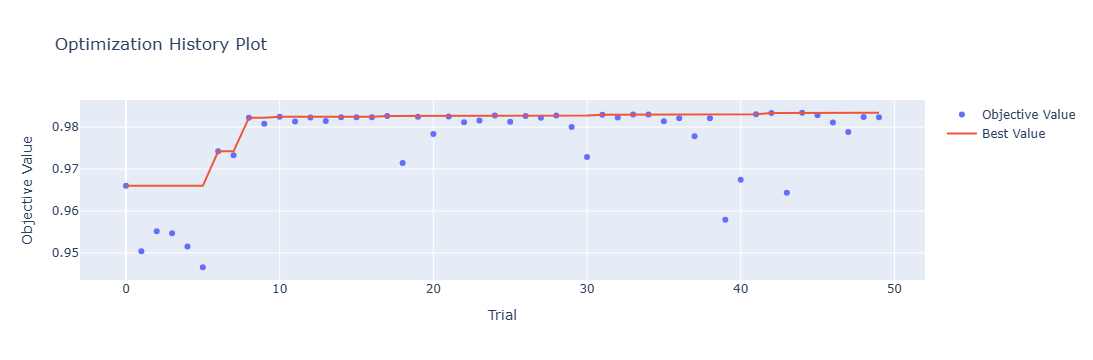

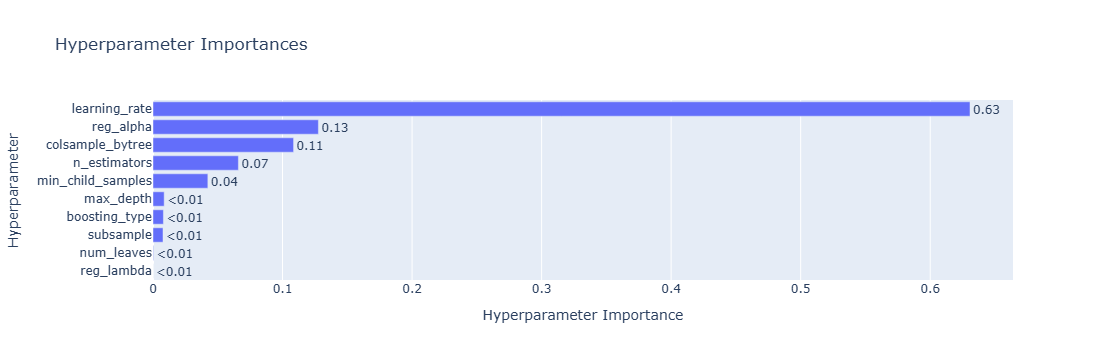

In [8]:
# Plot Optimization History
try:
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.show()
except Exception as e:
    print(f"Plotly visualization fallback: {e}")

# Plot Hyperparameter Importances
try:
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.show()
except Exception as e:
    print(f"Plotly visualization fallback: {e}")

## 9. Comprehensive Comparison Benchmark

,Method,Test ROC-AUC,Execution Time (s)
0,Baseline (Default),0.987055,1.727715
1,GridSearchCV,0.986364,45.570929
2,RandomizedSearchCV,0.987446,39.256453
3,Optuna (TPE),0.987808,73.023340


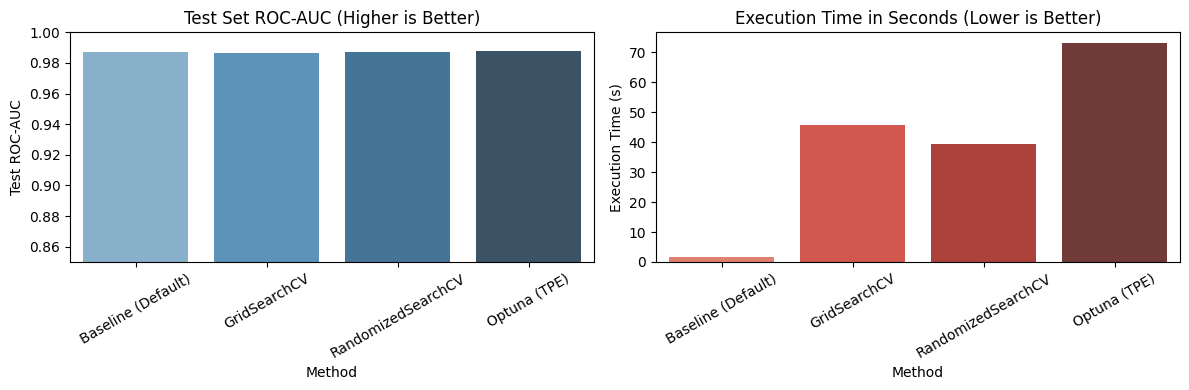

In [9]:
benchmark_df = pd.DataFrame({
    'Method': ['Baseline (Default)', 'GridSearchCV', 'RandomizedSearchCV', 'Optuna (TPE)'],
    'Test ROC-AUC': [baseline_auc, grid_auc, rand_auc, optuna_test_auc],
    'Execution Time (s)': [baseline_time, grid_time, rand_time, optuna_time]
})

display(benchmark_df)

# Visualization of Benchmark
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=benchmark_df, x='Method', y='Test ROC-AUC', ax=axes[0], palette='Blues_d')
axes[0].set_title('Test Set ROC-AUC (Higher is Better)')
axes[0].set_ylim(0.85, 1.0)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=benchmark_df, x='Method', y='Execution Time (s)', ax=axes[1], palette='Reds_d')
axes[1].set_title('Execution Time in Seconds (Lower is Better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 📌 Key Takeaways & Summary

1. **GridSearchCV**: Best for small parameter grids (<=3 parameters). Scale is $O(K^N)$ which quickly becomes prohibitive.
2. **RandomizedSearchCV**: Good for fast initial exploration, but samples blindly without leveraging trial history.
3. **Optuna Framework**: Industry standard Bayesian optimization. Uses TPE to focus on high-performing search sub-spaces.
4. **Log Scale Sampling**: Use `log=True` for hyperparameters spanning multiple orders of magnitude (`learning_rate`, `reg_alpha`, `reg_lambda`).
5. **Pruning**: `MedianPruner` allows early stopping of unpromising hyperparameter trials, dramatically reducing training costs.